In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import logsumexp
import pickle
import json
import os
import time
from plotting_functions import plot_method_comparison, plot_gillespie_nmc_comparison
from saving_experiments import save_samples, load_samples, save_samples_summary
from main_code import run_diffusion_experiment, add_gillespie_reverse, add_tau_leap_reverse
from add_methods_utils import add_methods_to_lightweight_file

In [ ]:
# Define tau-leaping methods with different tau values
tau_methods = []

for tau in [0.1, 0.01,0.008, 0.005]:
    tau_methods.append({
        'type': 'tau_leap',
        'tau': tau,
        'corrector': False
    })

# Add them to the file
print("Adding tau-leaping methods to gillespie_nmc_300000.pkl...")
results = add_methods_to_lightweight_file(
    'gillespie_nmc_300000.pkl',
    tau_methods
)

print(f"\n✓ Added {len(results['methods_added'])} tau-leaping methods!")
print("Methods added:")
for method in results['methods_added']:
    print(f"  - {method}")

Adding tau-leaping methods to gillespie_nmc_1000.pkl...
ADDING METHODS TO LIGHTWEIGHT SAVE

Loading: gillespie_nmc_1000.pkl
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_1000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 1 methods
  - n_mc: 1000, N: 3, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
✓ Lightweight format confirmed

Parameters: N=3, L=3, beta=5.0, T=3.5, n_mc=1000
Existing methods (1): ['gillespie']

Adding 5 new methods...

[1/5] Adding: tau=0.5, no corrector
Running tau-leaping (tau=0.5) reverse process...
  Tau-leap particle 0/1000
  ✓ Completed in 0.67 seconds
  Method: tau_leap_0.5

[2/5] Adding: tau=0.1, no corrector
Running tau-leaping (tau=0.1) reverse process...
  Tau-leap particle 0/1000
  ✓ Completed in 2.41 seconds
  Method: tau_leap_0.1

[3/5] Adding: tau=0.01, no corrector
Running tau-leaping (tau=0.01) reverse process...
  Tau-leap partic

Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_500.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 9 methods
  - n_mc: 500, N: 3, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Computing Hellinger distances from joint PMFs...

Generating plot for methods: ['gillespie', 'tau_leap_0.01', 'tau_leap_0.01_corrector_PRISM_start_2.0_eta_0.5', 'tau_leap_0.005', 'tau_leap_0.005_corrector_PRISM_start_2.0_eta_0.5', 'tau_leap_0.005_corrector_informed_corrector_start_2.0_K_2_ncorr_8_gamma_1.0_margin', 'tau_leap_0.01_corrector_random_masking_start_2.0_ncorr_5_tauc_0.002', 'tau_leap_0.01_corrector_random_masking_start_2.0_ncorr_5_tauc_0.002_fwd_only', 'tau_leap_0.01_corrector_random_masking_start_2.0_ncorr_10_tauc_0.001']
Time range: [0.000, 3.500]
Plot saved to: all_methods_comparison_test.png


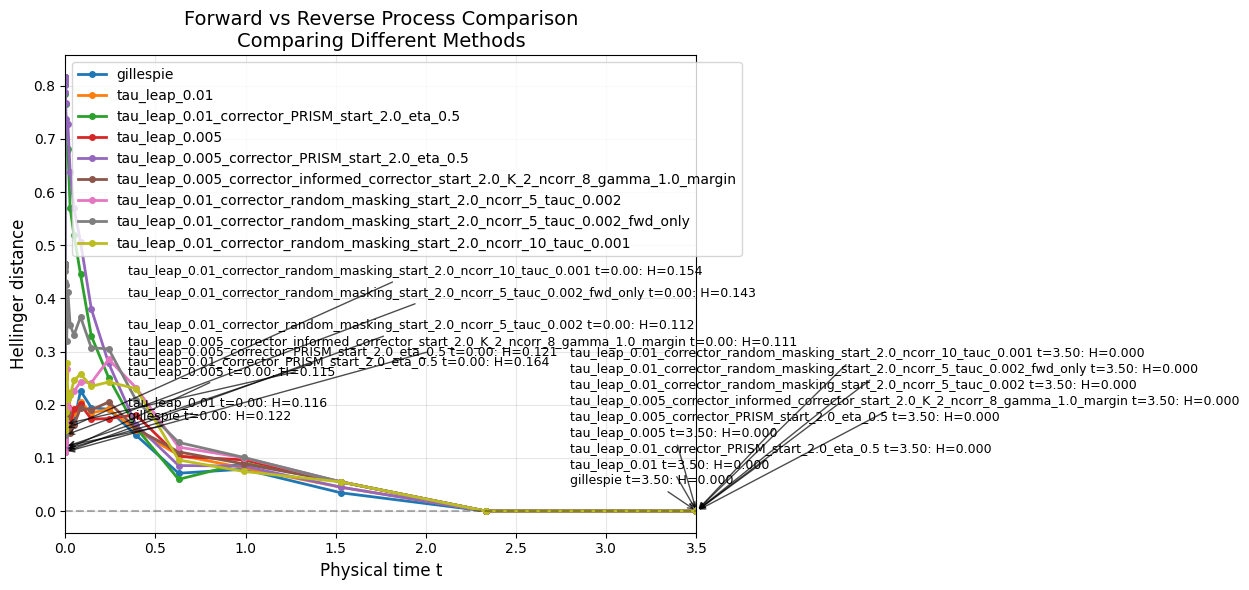

In [ ]:
data, metadata = load_samples('gillespie_nmc_300000.pkl')

# Plot all methods
plot_method_comparison(
    data,
    methods=None,  # None = plot all methods
    filename='all_methods_comparisont.png',
    show_annotations=True
)